# Brent Oil Price Change Point Analysis

## Task 1: Laying the Foundation for Analysis

### Author

Arsema Esayas

---

## Project Overview

This notebook focuses on understanding the Brent crude oil price dataset before any statistical modeling is performed. The objective is to investigate the characteristics of the time series, understand the business problem, inspect data quality, and prepare the dataset for Bayesian Change Point Analysis.

The notebook forms the foundation for subsequent modeling and dashboard development.

# Business Problem

Birhan Energies seeks to understand how major geopolitical events, economic shocks, international sanctions, wars, and OPEC policy decisions have influenced Brent crude oil prices over time.

Understanding these structural changes enables investors, policymakers, and energy companies to make better strategic decisions regarding investment, operational planning, and risk management.

# Objectives

The objectives of this notebook are:

1. Load and inspect the Brent oil price dataset.
2. Assess the quality of the dataset.
3. Explore trends and statistical properties.
4. Understand the assumptions behind Bayesian Change Point Analysis.
5. Prepare the data for modeling.
6. Document all preprocessing steps for reproducibility.

# Data Science Workflow

The analysis follows the workflow below:

1. Data Acquisition
2. Data Loading
3. Data Inspection
4. Data Cleaning
5. Exploratory Data Analysis
6. Time Series Analysis
7. Stationarity Assessment
8. Volatility Analysis
9. Bayesian Change Point Modeling
10. Interpretation of Results
11. Dashboard Development
12. Reporting and Documentation

In [1]:
# Standard Library Imports
import warnings

warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistical Analysis
from scipy import stats

# Time Series Analysis
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf

# Bayesian Modeling
import pymc as pm
import arviz as az

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

print("Libraries loaded successfully.")

Matplotlib is building the font cache; this may take a moment.
g++ not available, if using conda: `conda install gxx`


Libraries loaded successfully.


# Loading the Dataset

The Brent crude oil price dataset is loaded from the project's **data/raw** directory.

The original dataset is preserved without modification to ensure reproducibility. Any cleaned or transformed datasets created during this project will be saved separately in the **data/processed** directory.

In [2]:
# Load Dataset

DATA_PATH = "../data/raw/BrentOilPrices.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")

Dataset loaded successfully.


# Initial Dataset Inspection

Before performing any analysis, we inspect the dataset to understand its dimensions, structure, variable types, and the first few observations.

In [3]:
# Dataset Dimensions

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print()

print(df.head())

Rows: 9011
Columns: 2

        Date  Price
0  20-May-87  18.63
1  21-May-87  18.45
2  22-May-87  18.55
3  25-May-87  18.60
4  26-May-87  18.63


# Data Types

Correct data types are essential for time series analysis. We inspect the dataset to verify each variable's data type before preprocessing.

In [4]:
# Data Types

df.dtypes

Date         str
Price    float64
dtype: object

# Converting Date to Datetime

The Date column is currently stored as text (object type). It must be converted into Python's datetime format before performing time series analysis.

In [7]:
# Convert Date

df["Date"] = pd.to_datetime(
    df["Date"],
    format = 'mixed'
)

print(df.dtypes)

Date     datetime64[us]
Price           float64
dtype: object


# Date Range

Understanding the temporal coverage of the dataset is important for interpreting historical events and later validating detected change points.

In [8]:
# Date Range

print("Start Date :", df["Date"].min())
print("End Date   :", df["Date"].max())

print()

print("Number of Days:", len(df))

Start Date : 1987-05-20 00:00:00
End Date   : 2022-11-14 00:00:00

Number of Days: 9011


# Missing Value Analysis

Missing values can introduce bias or prevent statistical models from fitting correctly. We therefore inspect each variable for null values.

In [10]:
# Missing Values

df.isnull().sum()

Date     0
Price    0
dtype: int64

# Duplicate Record Analysis

Duplicate observations may distort trend estimation and statistical inference. We therefore check whether duplicate rows exist in the dataset.

In [11]:
# Duplicate Rows

duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


# Descriptive Statistics

Descriptive statistics provide an overview of the distribution of Brent crude oil prices, including measures of central tendency and variability.

In [12]:
# Summary Statistics

df.describe()

,Date,Price
count,9011,9011.000000
mean,2005-02-10 23:46:53.760958,48.420782
min,1987-05-20 00:00:00,9.100000
25%,1996-03-20 12:00:00,19.050000
50%,2005-02-02 00:00:00,38.570000
75%,2014-01-09 12:00:00,70.090000
max,2022-11-14 00:00:00,143.950000
std,NaN,32.860110


# Data Quality Assessment

## Findings

- The dataset contains two variables: Date and Price.
- The Date column was successfully converted into datetime format.
- No missing values were identified.
- No duplicate observations were detected.
- The dataset spans more than three decades of Brent crude oil prices, providing sufficient historical coverage for long-term structural break analysis.

## Conclusion

The dataset is considered suitable for exploratory analysis and Bayesian Change Point Modeling without requiring major cleaning operations.

# Exploratory Data Analysis (EDA)

The purpose of this exploratory analysis is to understand the long-term behavior of Brent crude oil prices before developing the Bayesian Change Point Model.

The analysis focuses on:

- Overall price trend
- Distribution of prices
- Price variability
- Time series characteristics
- Potential structural changes

# Historical Brent Oil Prices

The first step is to visualize the complete Brent oil price history. This allows us to identify long-term trends, major price shocks, and periods of unusual market behavior.

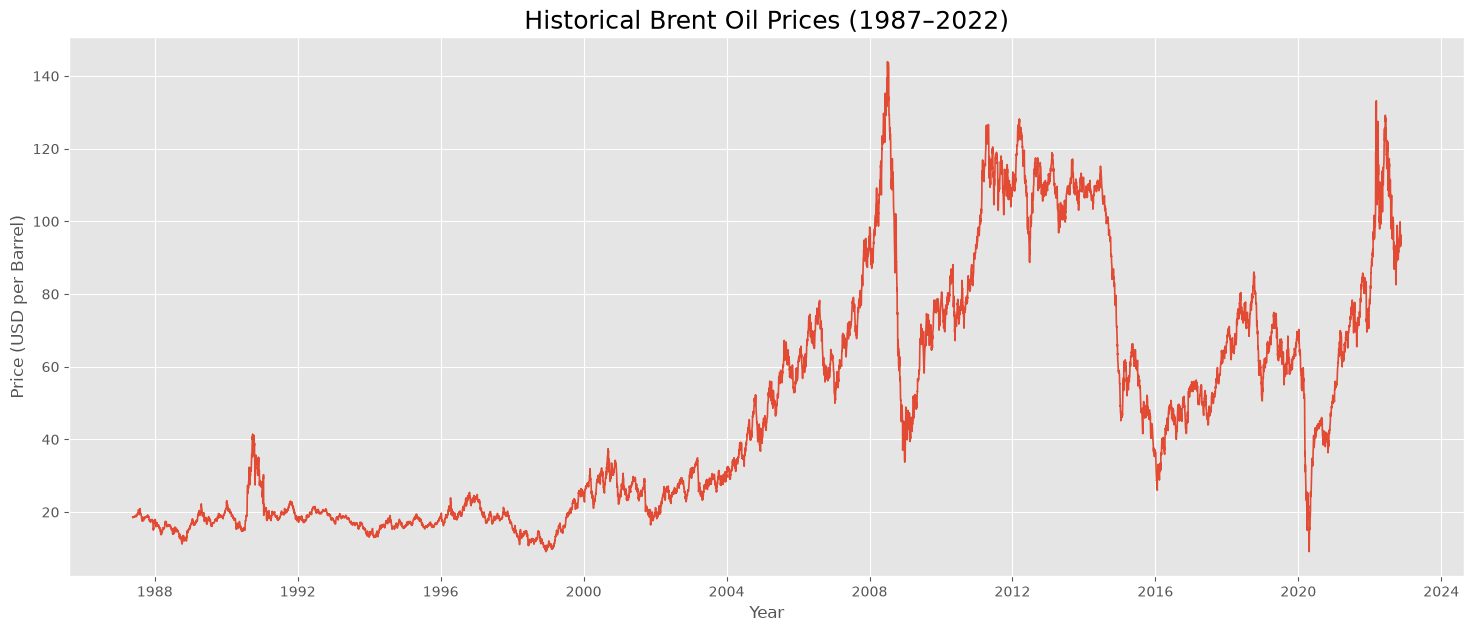

In [13]:
# Historical Brent Oil Prices

plt.figure(figsize=(18,7))

plt.plot(
    df["Date"],
    df["Price"],
    linewidth=1.2
)

plt.title("Historical Brent Oil Prices (1987–2022)", fontsize=18)

plt.xlabel("Year")

plt.ylabel("Price (USD per Barrel)")

plt.grid(True)

plt.show()

## Interpretation

Several important observations can immediately be made:

- Brent crude oil prices exhibit substantial fluctuations over time.
- Long periods of relatively stable prices are interrupted by sudden increases and decreases.
- Large spikes and crashes suggest the presence of structural changes rather than random variation.
- These observations motivate the use of Bayesian Change Point Analysis to identify statistically significant changes in the price-generating process.

# Distribution of Brent Oil Prices

The distribution of oil prices helps us understand whether prices follow a symmetric distribution or exhibit skewness and extreme values.

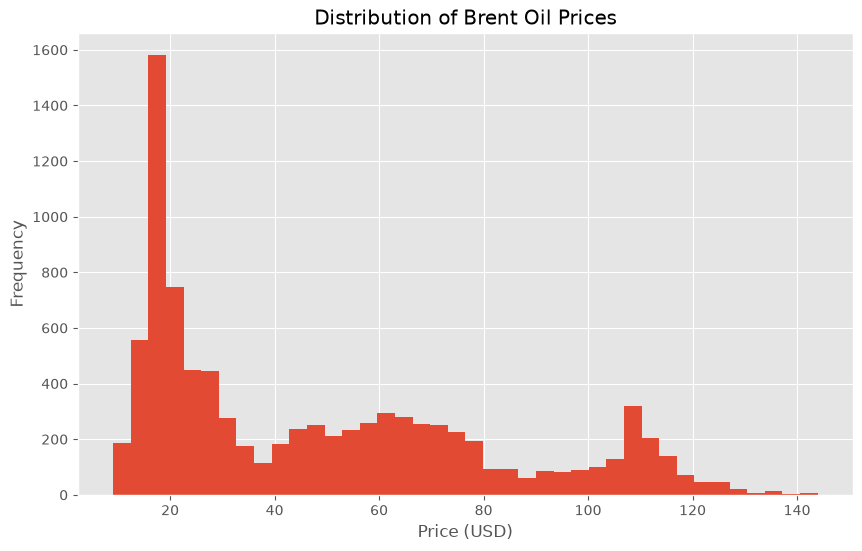

In [14]:
# Histogram

plt.figure(figsize=(10,6))

plt.hist(
    df["Price"],
    bins=40
)

plt.title("Distribution of Brent Oil Prices")

plt.xlabel("Price (USD)")

plt.ylabel("Frequency")

plt.show()

## Interpretation

The histogram illustrates the overall distribution of Brent crude oil prices over the entire observation period.

The distribution is not perfectly symmetric, indicating that oil prices spend longer periods within certain price ranges while extreme market events generate unusually high or low prices.

# Box Plot

A box plot summarizes the distribution of Brent oil prices and highlights potential outliers that may correspond to major geopolitical or economic events.

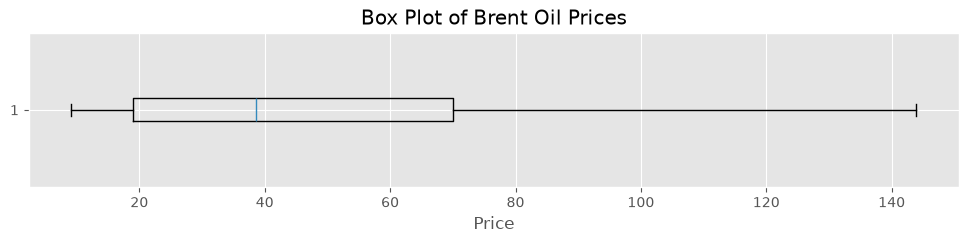

In [15]:
# Box Plot

plt.figure(figsize=(12,2))

plt.boxplot(
    df["Price"],
    vert=False
)

plt.title("Box Plot of Brent Oil Prices")

plt.xlabel("Price")

plt.show()

## Interpretation

The box plot reveals several observations far from the median.

These extreme values likely correspond to significant market events such as financial crises, wars, production cuts, or global disruptions.

Rather than treating these observations as errors, they represent economically meaningful events and should therefore remain in the dataset.

# Rolling Mean

Rolling averages smooth short-term fluctuations and reveal longer-term market trends.

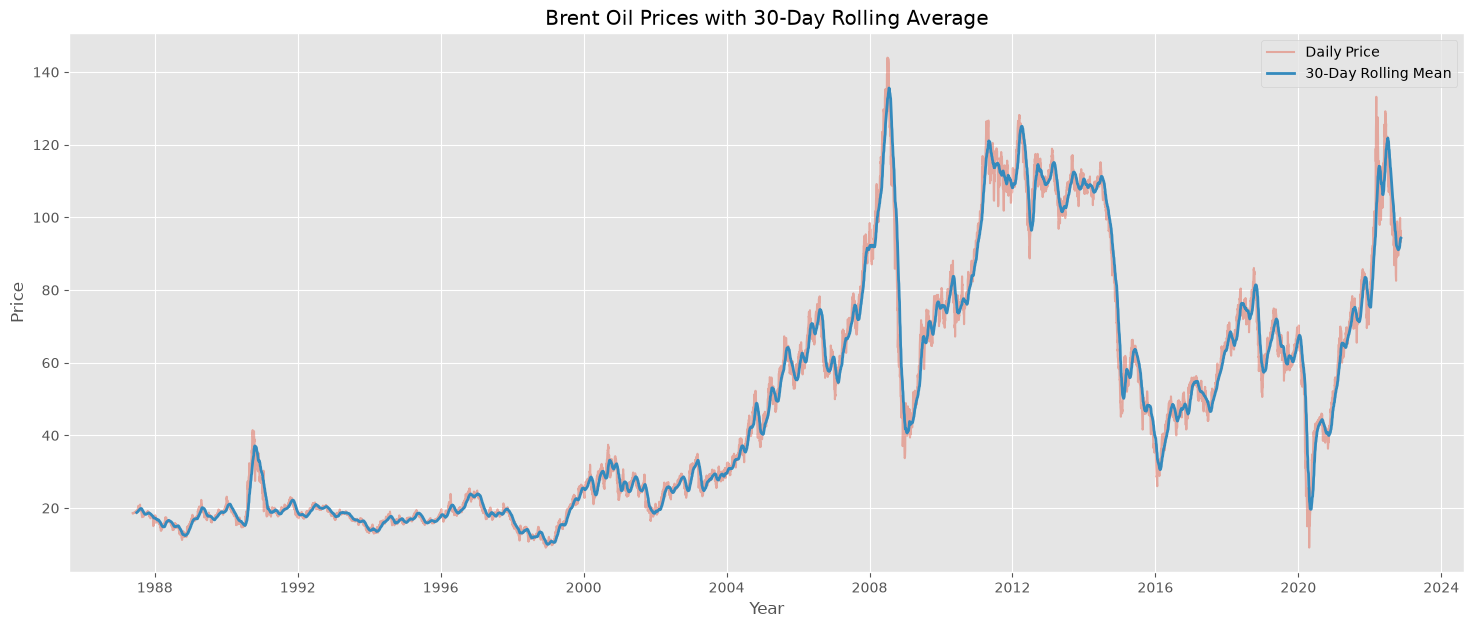

In [16]:
# 30-Day Rolling Mean

df["RollingMean30"] = df["Price"].rolling(window=30).mean()

plt.figure(figsize=(18,7))

plt.plot(
    df["Date"],
    df["Price"],
    alpha=0.4,
    label="Daily Price"
)

plt.plot(
    df["Date"],
    df["RollingMean30"],
    linewidth=2,
    label="30-Day Rolling Mean"
)

plt.title("Brent Oil Prices with 30-Day Rolling Average")

plt.xlabel("Year")

plt.ylabel("Price")

plt.legend()

plt.show()

## Interpretation

The rolling average smooths daily price fluctuations and highlights sustained upward and downward trends.

Sharp deviations between the daily price and the rolling mean often correspond to periods of heightened market volatility.

# Rolling Volatility

The rolling standard deviation measures how much prices fluctuate over time and provides an indication of market volatility.

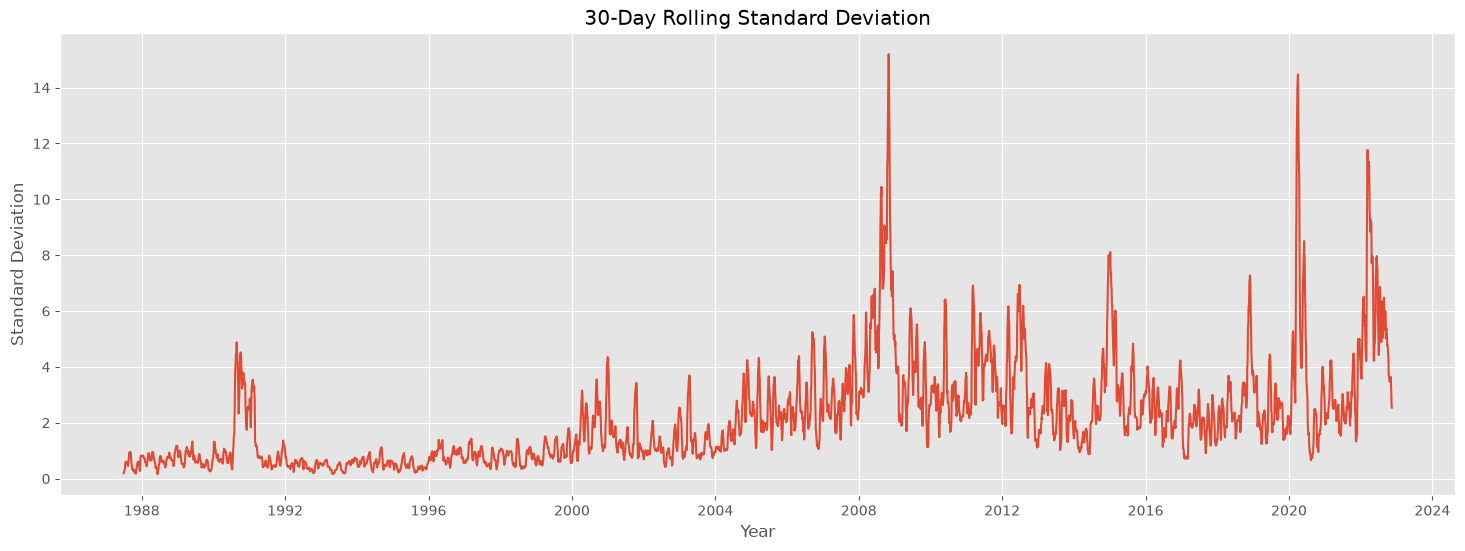

In [17]:
# Rolling Standard Deviation

df["RollingSTD30"] = df["Price"].rolling(window=30).std()

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["RollingSTD30"]
)

plt.title("30-Day Rolling Standard Deviation")

plt.xlabel("Year")

plt.ylabel("Standard Deviation")

plt.show()

## Interpretation

Periods with higher rolling standard deviation indicate greater market uncertainty and increased price volatility.

These periods often coincide with major geopolitical events, financial crises, or disruptions in global oil supply.

# Distribution Shape

Skewness and kurtosis provide numerical measures of the distribution's shape.

In [18]:
# Skewness and Kurtosis

print("Skewness :", df["Price"].skew())

print("Kurtosis :", df["Price"].kurt())

Skewness : 0.7653045224332105
Kurtosis : -0.6104398901218295


## Interpretation

- Skewness measures the symmetry of the distribution.
- Kurtosis measures the heaviness of the distribution tails.

Non-zero skewness and elevated kurtosis suggest that Brent oil prices do not follow a perfectly normal distribution and may experience extreme events more frequently than expected under a normal distribution.

# Correlation Matrix

At this stage, only numerical variables generated during preprocessing are available. The correlation matrix helps examine relationships among these variables.

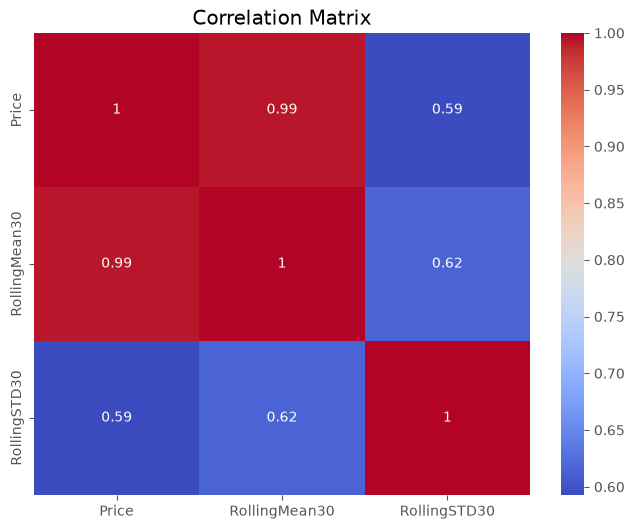

In [19]:
# Correlation Matrix

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Interpretation

The correlation matrix confirms that the rolling statistics are strongly related to the original price series, as expected. These engineered variables are useful for exploratory analysis but will not be directly used in the Bayesian Change Point Model developed later.

# Time Series Analysis

Before constructing the Bayesian Change Point Model, it is essential to understand the statistical properties of the Brent oil price series.

This section investigates:

- Long-term trend
- Stationarity
- Volatility
- Temporal dependence
- Suitability for Bayesian Change Point Analysis

# Trend Analysis

A time series trend represents the long-term direction of movement in the data.

Visual inspection of Brent oil prices suggests that prices do not fluctuate around a constant mean. Instead, long-term upward and downward movements are observed, indicating that the series is likely non-stationary.

# Log Transformation

Financial time series are often analyzed using logarithms because percentage changes are generally more informative than absolute price differences.

Taking logarithms also helps stabilize variance and prepares the data for return calculations.

In [20]:
# Log Price

df["LogPrice"] = np.log(df["Price"])

print(df[["Price", "LogPrice"]].head())

   Price  LogPrice
0  18.63  2.924773
1  18.45  2.915064
2  18.55  2.920470
3  18.60  2.923162
4  18.63  2.924773


# Log Price Series

The logarithm of Brent oil prices compresses the scale of the data while preserving its overall structure.

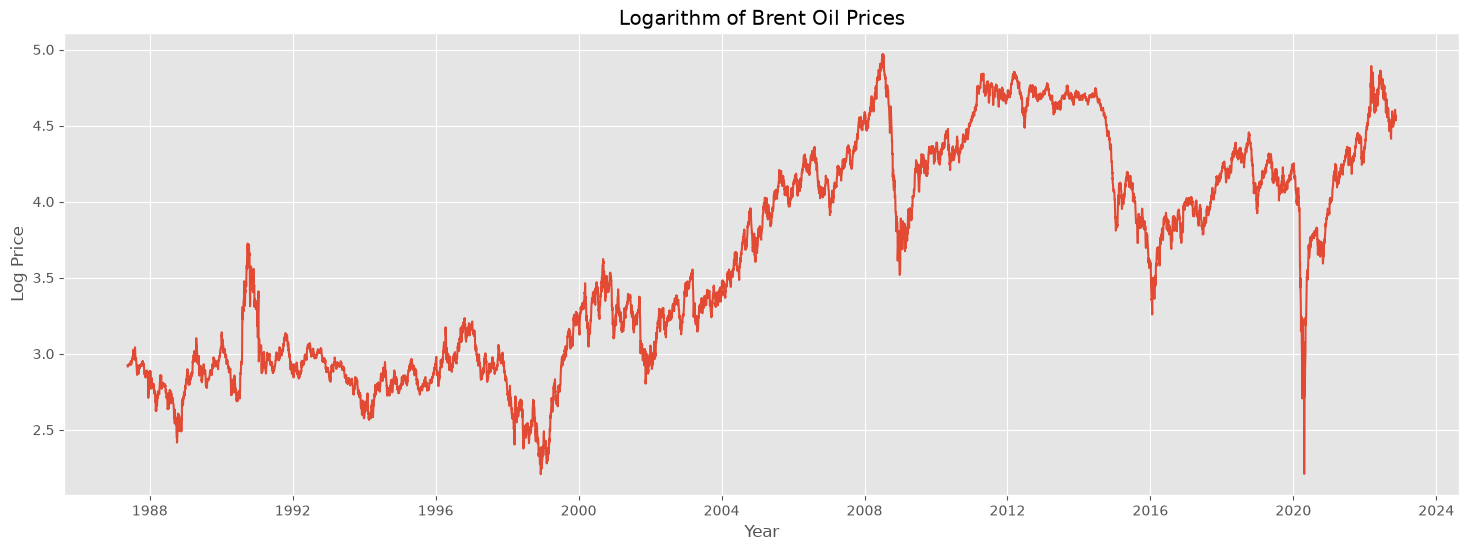

In [21]:
# Log Price Series

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"],
    df["LogPrice"]
)

plt.title("Logarithm of Brent Oil Prices")

plt.xlabel("Year")

plt.ylabel("Log Price")

plt.grid(True)

plt.show()

## Interpretation

The logarithmic transformation reduces the visual impact of extreme price movements while preserving long-term trends.

However, the series still exhibits noticeable changes in its mean over time, suggesting that it remains non-stationary.

# Log Returns

Instead of modeling prices directly, financial analysts frequently examine log returns.

Log returns measure proportional daily changes and often exhibit more stable statistical properties than raw prices.

In [22]:
# Log Returns

df["LogReturn"] = np.log(df["Price"]).diff()

df.head()

,Date,Price,RollingMean30,RollingSTD30,LogPrice,LogReturn
0,1987-05-20,18.63,NaN,NaN,2.924773,NaN
1,1987-05-21,18.45,NaN,NaN,2.915064,-0.009709
2,1987-05-22,18.55,NaN,NaN,2.920470,0.005405
3,1987-05-25,18.60,NaN,NaN,2.923162,0.002692
4,1987-05-26,18.63,NaN,NaN,2.924773,0.001612


# Removing Missing Values

The first log return is undefined because there is no previous observation from which to compute a return.

This missing value is removed before further analysis.

In [23]:
# Remove Missing Values

returns = df["LogReturn"].dropna()

print("Number of observations:", len(returns))

Number of observations: 9010


# Log Return Series

Visualizing log returns allows us to identify periods of unusually high market volatility and determine whether returns fluctuate around a stable mean.

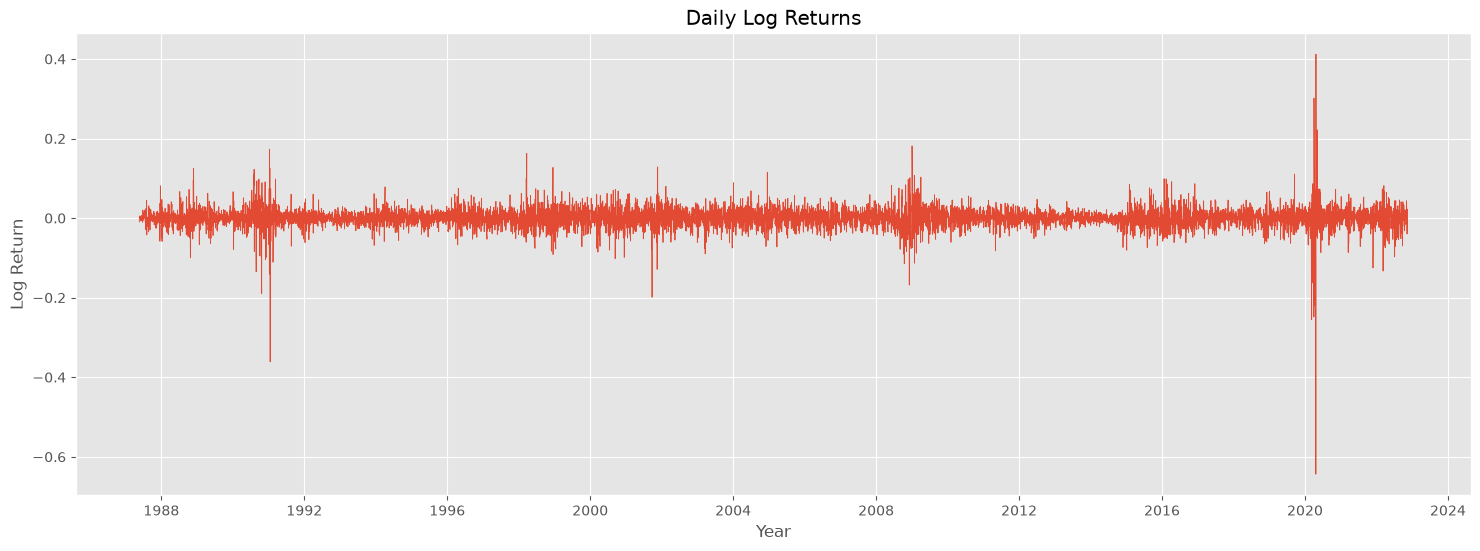

In [24]:
# Log Return Plot

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"][1:],
    returns,
    linewidth=0.6
)

plt.title("Daily Log Returns")

plt.xlabel("Year")

plt.ylabel("Log Return")

plt.grid(True)

plt.show()

## Interpretation

Unlike the original price series, log returns fluctuate around a value close to zero.

However, the magnitude of fluctuations changes over time, indicating periods of high and low volatility.

This phenomenon is known as volatility clustering.

# Volatility Clustering

Financial markets often exhibit volatility clustering, where large price movements tend to be followed by additional large movements.

This behavior is clearly visible in Brent oil returns.

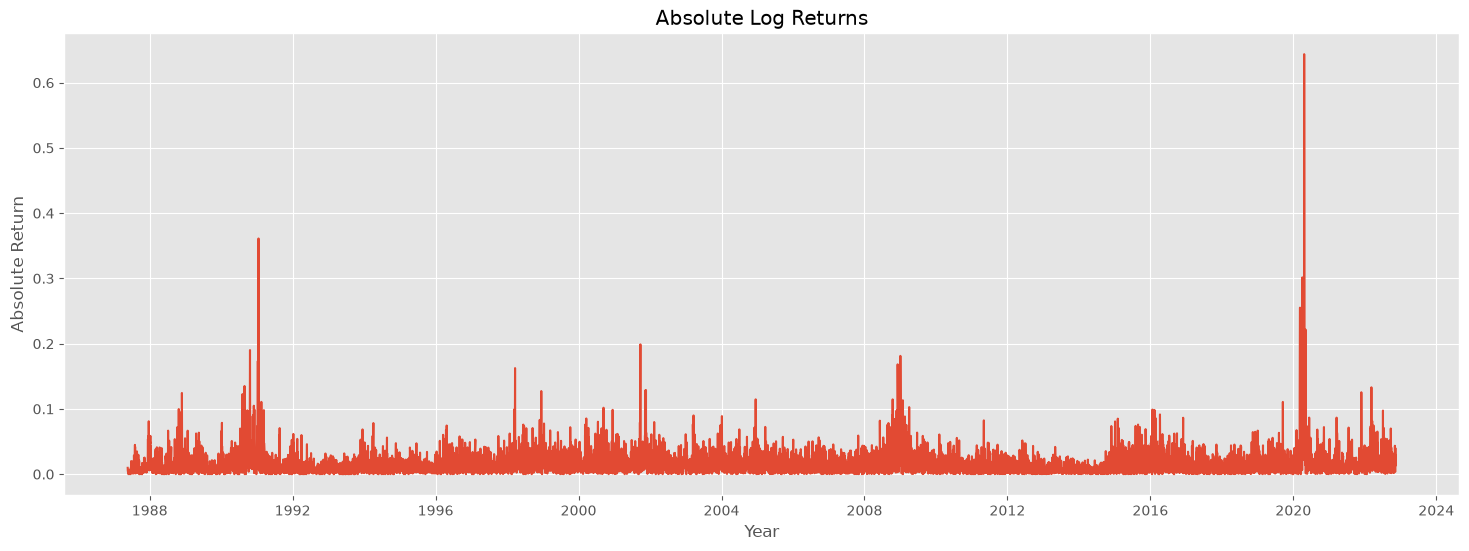

In [25]:
# Absolute Returns

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"][1:],
    np.abs(returns)
)

plt.title("Absolute Log Returns")

plt.xlabel("Year")

plt.ylabel("Absolute Return")

plt.show()

## Interpretation

Periods of heightened volatility appear in clusters rather than occurring randomly.

These clusters often correspond to periods of economic uncertainty or geopolitical instability.

# Augmented Dickey-Fuller Test

The Augmented Dickey-Fuller (ADF) test evaluates whether a time series contains a unit root.

Hypotheses:

- H₀: The series is non-stationary.
- H₁: The series is stationary.

In [26]:
# Augmented Dickey-Fuller Test

adf_result = adfuller(returns)

print("ADF Statistic :", adf_result[0])

print("p-value :", adf_result[1])

print()

print("Critical Values")

for key, value in adf_result[4].items():
    print(key, ":", value)

ADF Statistic : -16.427113494485894
p-value : 2.4985801611428892e-29

Critical Values
1% : -3.4310783342658615
5% : -2.861861876398633
10% : -2.566941329781918


## Interpretation

If the p-value is below 0.05, we reject the null hypothesis and conclude that the log return series is stationary.

Stationary log returns are generally more appropriate for statistical modeling than raw prices because their statistical properties remain relatively constant over time.

# Rolling Mean of Returns

A stationary series should fluctuate around a relatively constant mean.

The rolling mean provides a visual assessment of this property.

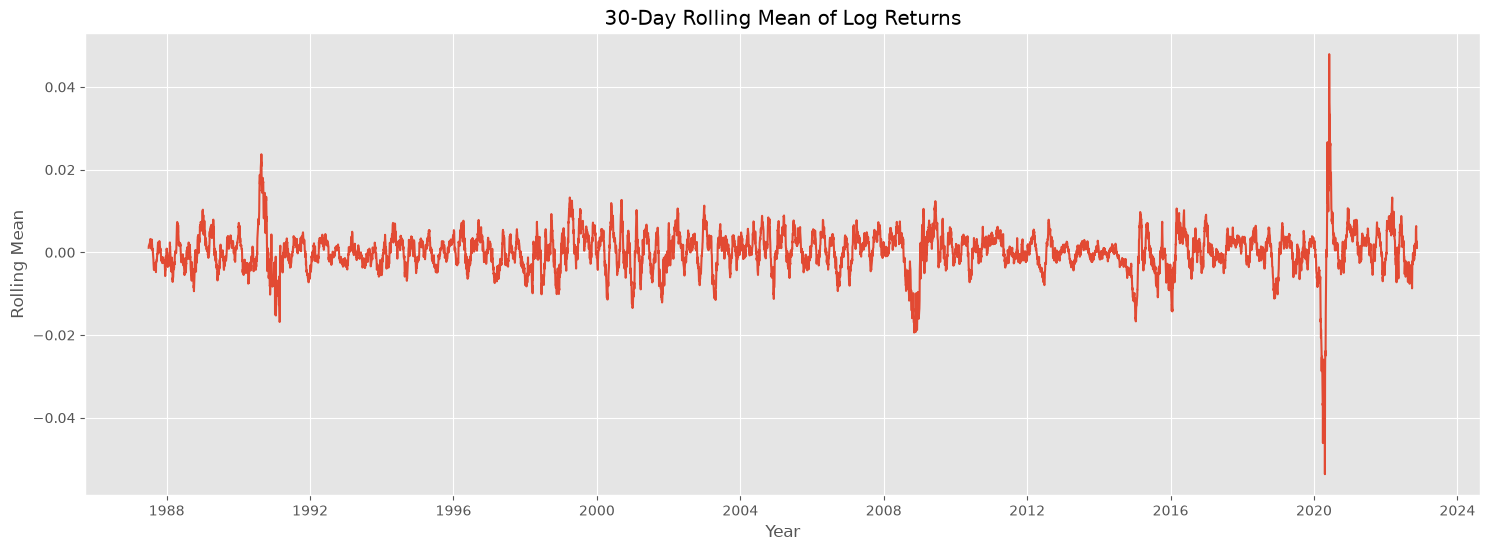

In [27]:
# Rolling Mean

rolling_mean = returns.rolling(window=30).mean()

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"][1:],
    rolling_mean
)

plt.title("30-Day Rolling Mean of Log Returns")

plt.xlabel("Year")

plt.ylabel("Rolling Mean")

plt.show()

# Rolling Variance

A stationary process should also exhibit relatively stable variance over time.

We therefore inspect the rolling standard deviation of the log returns.

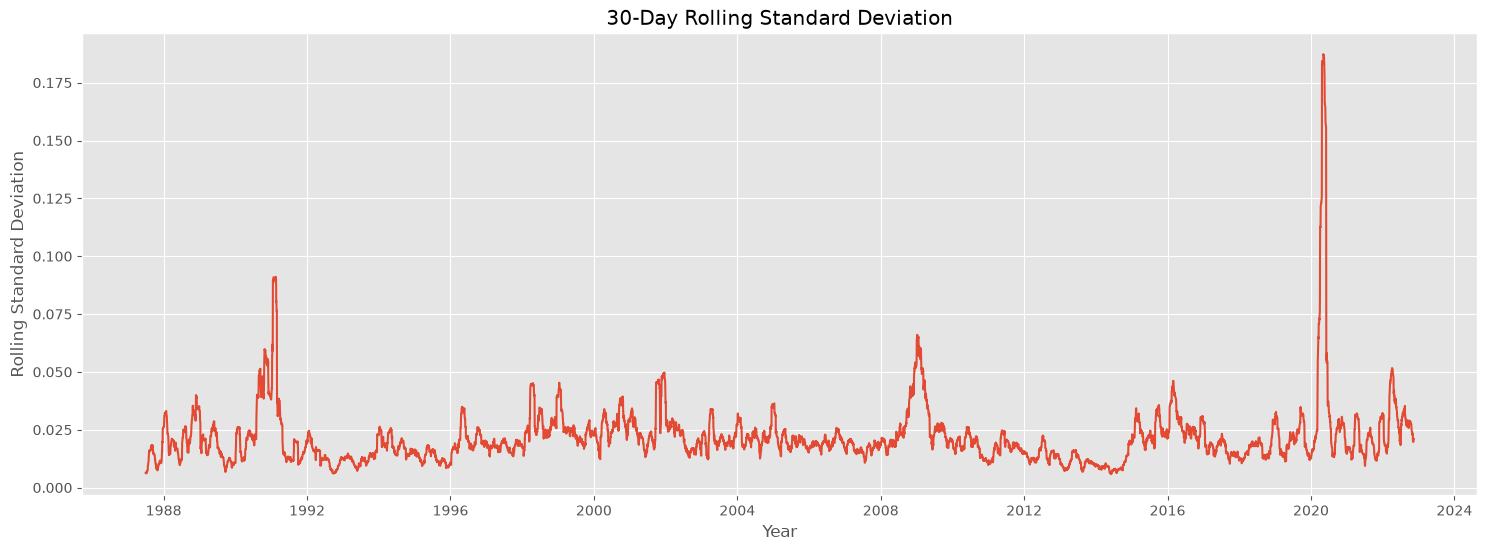

In [28]:
# Rolling Standard Deviation

rolling_std = returns.rolling(window=30).std()

plt.figure(figsize=(18,6))

plt.plot(
    df["Date"][1:],
    rolling_std
)

plt.title("30-Day Rolling Standard Deviation")

plt.xlabel("Year")

plt.ylabel("Rolling Standard Deviation")

plt.show()

# Autocorrelation Function (ACF)

The ACF measures correlation between observations separated by different time lags.

Strong autocorrelation suggests temporal dependence in the series.

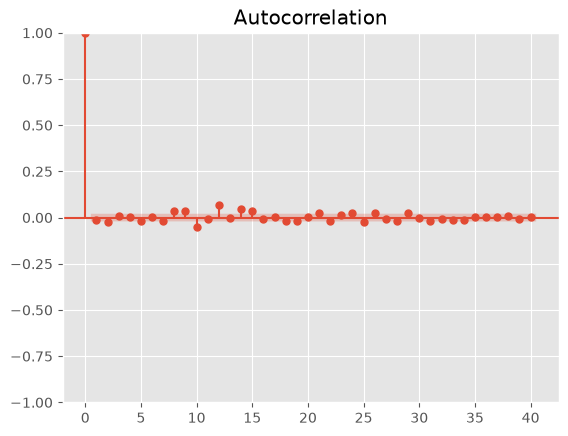

In [29]:
# ACF

plot_acf(
    returns,
    lags=40
)

plt.show()

# Partial Autocorrelation Function (PACF)

The PACF measures direct relationships between observations while removing indirect effects from intermediate lags.

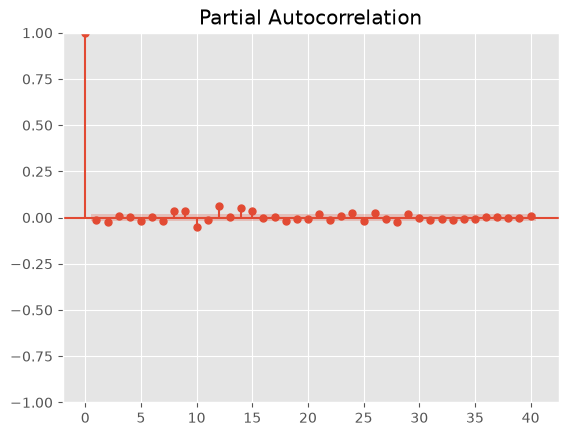

In [30]:
# PACF

plot_pacf(
    returns,
    lags=40
)

plt.show()

# Implications for Bayesian Change Point Modeling

The time series analysis provides several important insights:

1. The original Brent oil price series exhibits clear long-term trends and structural shifts.
2. Log returns fluctuate around a relatively constant mean and are substantially more stationary than raw prices.
3. Volatility clustering indicates that periods of market instability occur in groups rather than randomly.
4. The ADF test provides statistical evidence regarding stationarity of the return series.
5. These findings support the use of Bayesian Change Point Analysis to identify structural breaks associated with major geopolitical and economic events.

Rather than assuming that one statistical model explains the entire 35-year period, the Bayesian Change Point Model allows different statistical parameters before and after detected change points, making it well suited to modeling major market transitions.